# Label Propagation — Projection Ablation

Reproduces APORIA-LP ablation experiment under different projection geometries (Appendix F) -- Wasserstein-on-X label propagation under Whitened PCA, Random Projection, and Supervised UMAP, varying number of components (Figure 12; Table 14).

---

## Setup

In [1]:
import os
import pathlib

# allow execution from either the repo root or code/
ROOT = pathlib.Path.cwd()
if ROOT.name == "code":
    os.chdir(ROOT.parent)
    
os.environ["OPENBLAS_NUM_THREADS"] = "4"


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import aporia as ap


In [3]:
# ---------------------------------------------------------------
# Load dataset + model metadata from a TOML config.
# ---------------------------------------------------------------
CONFIG_PATH = "config/socrates.toml"

cfg = ap.load_config(CONFIG_PATH)

# expose aliases used downstream
model_names           = cfg.model_names
figures_dir           = cfg.cache.fig_dir
model_latextags       = cfg.model_latextags
best_reg_lambda       = cfg.experiment.best_lambda
maxResponsesPerPrompt = cfg.dataset.max_responses_per_prompt


In [4]:
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = ap.matplotlib_latex_preamble(cfg)


## Data

In [5]:
df = ap.load_dataframe(cfg)


In [6]:
import time
from tqdm.auto import tqdm

minutes = 0   # set > 0 to delay execution (e.g. overnight scheduling)
for _ in tqdm(range(minutes), desc="Sleeping before execution"):
    time.sleep(60)


Sleeping before execution: 0it [00:00, ?it/s]

## Experiment

In [7]:
results_fisher = ap.run_full_label_propagation_study(
    df, cfg,
    projector_class  = ap.FisherProjection,
    projector_kwargs = {
        "lambda_reg":          best_reg_lambda,
        "normalise":           True,
        "normalise_by_trace":  True,
    },
    train_fractions  = None,
    n_iter           = 100,
    test_fraction    = 1/3,
    n_splits         = 10,
    ref_lambda_reg   = best_reg_lambda,
    use_cache        = True,
    cache_dir        = f"{cfg.cache.root}/PA_fisher",
    overwrite_cache  = False,
    logskip          = True,
)


Model:   0%|          | 0/10 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

...

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

In [8]:
ncomps  = [1, 2, 3, 5, 10, 15]
methods = {
    "wPCA": ap.WhitenedPCAProjection,
    "EP":   ap.RandomProjection,
    "UMAP": ap.SupervisedUMAPProjection,
}

results = {}
for method_label, method_cls in methods.items():
    results[method_label] = {}
    for ncomp in ncomps:
        print("Running", method_label, "with", ncomp, "components.")
        args = {"n_components": ncomp, "random_state": 42}
        if method_label == "UMAP":
            args["n_neighbors"] = 10
            args["min_dist"]    = 0.1
        results[method_label][ncomp] = ap.run_full_label_propagation_study(
            df, cfg,
            projector_class  = method_cls,
            projector_kwargs = args,
            train_fractions  = None,
            n_iter           = 100,
            test_fraction    = 1/3,
            ref_lambda_reg   = best_reg_lambda,
            n_splits         = 10,
            use_cache        = True,
            cache_dir        = f"{cfg.cache.root}/PA_{method_label}_{ncomp}",
            logskip          = True,
        )


Running wPCA with 1 components.


Model:   0%|          | 0/10 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

...

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

In [9]:
def tag_results(df, method, n_components):
    out = df.copy()
    out["method"] = method
    out["n_components"] = n_components
    return out

dfs = []

dfs.append(tag_results(results_fisher, "Fisher", 1))

for method_label in methods:
    for ncomp in ncomps:
        dfs.append(tag_results(results[method_label][ncomp], method_label, ncomp))

df_all = pd.concat(dfs, ignore_index=True)

# ====

summary = (
    df_all
    .groupby(["method", "n_components"])
    .agg(
        acc_mean=("accuracy", "mean"),
        acc_std=("accuracy", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        margin_mean=("mean_margin", "mean"),
        agreement_mean=("agreement_fisher", "mean"),
        agreement_std=("agreement_fisher", "std"),
        agreement_conf_mean=("agreement_fisher_confident", "mean"),
        agreement_conf_std=("agreement_fisher_confident", "std"),
    )
    .reset_index()
)

## Figures and tables

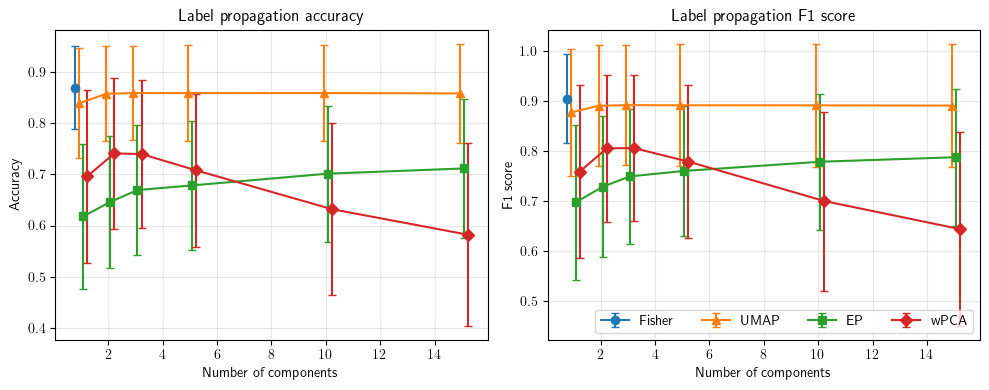

In [10]:
methods = summary["method"].unique()
methods = methods[[1,2,0,3]]

offset_map = {
    m: (i - (len(methods) - 1) / 2) * 0.15
    for i, m in enumerate(methods)
}

marker_map = {
    "Fisher": "o",
    "EP": "s",
    "UMAP": "^",
    "wPCA": "D",
}

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

# === Accuracy panel ===
for method in methods:
    sub = summary[summary["method"] == method]
    x = sub["n_components"] + offset_map[method]

    axes[0].errorbar(
        x,
        sub["acc_mean"],
        yerr=sub["acc_std"],
        marker=marker_map.get(method, "o"),
        linestyle="-",
        capsize=3,
        label=method,
    )

axes[0].set_ylabel("Accuracy")
axes[0].set_title("Label propagation accuracy")
axes[0].grid(alpha=0.3)


# === F1 panel ===
for method in methods:
    sub = summary[summary["method"] == method]
    x = sub["n_components"] + offset_map[method]

    axes[1].errorbar(
        x,
        sub["f1_mean"],
        yerr=sub["f1_std"],
        marker=marker_map.get(method, "o"),
        linestyle="-",
        capsize=3,
        label=method,
    )

axes[1].set_ylabel("F1 score")
axes[1].set_title("Label propagation F1 score")
axes[1].grid(alpha=0.3)


# === Shared formatting ===
for ax in axes:
    ax.set_xlabel("Number of components")

axes[1].legend(loc="lower right", ncols=4)
plt.tight_layout()
fig.savefig(f"{figures_dir}/ProjectorsAnalysis.pdf", bbox_inches='tight')

In [11]:
best_by_method = (
    summary
    .sort_values("acc_mean", ascending=False)
    .groupby("method")
    .first()
    .reset_index()
)

table = best_by_method[
    ["method", "n_components", "acc_mean", "acc_std", "f1_mean", "f1_std", "margin_mean", "agreement_mean", "agreement_std", "agreement_conf_mean", "agreement_conf_std"]
]

table = table.rename(columns={
    "n_components": "dim",
    "acc_mean": "accuracy",
    "acc_std": "std",
    "margin_mean": "mean margin",
    "f1_mean": "f1",
})

table

,method,dim,accuracy,std,f1,f1_std,mean margin,agreement_mean,agreement_std,agreement_conf_mean,agreement_conf_std
0,EP,15,0.711637,0.135437,0.788036,0.136731,-0.514683,0.712977,0.140499,0.789018,0.160622
1,Fisher,1,0.869576,0.080941,0.904754,0.088423,-0.547056,1.000000,0.000000,1.000000,0.000000
2,UMAP,5,0.858985,0.093911,0.891698,0.121527,-6.629457,0.889466,0.087909,0.970305,0.069827
3,wPCA,2,0.741040,0.148253,0.805833,0.146567,-0.037927,0.754746,0.156960,0.831341,0.168609


The fact that Fisher outperforms UMAP while operating in one dimension strongly suggests that class-separating information is predominantly linear and aligned with between-class mean differences, rather than encoded in nonlinear local geometry.

In [12]:
summary = (
    df_all
    .groupby(["method", "n_components"])
    .agg(
        # performance
        acc_mean=("accuracy", "mean"),
        acc_std=("accuracy", "std"),

        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),

        # signed margin (already computed per run)
        margin_mean=("mean_margin", "mean"),
        margin_std=("std_margin", "mean"),

        # absolute margin (already computed per run)
        abs_margin_mean=("mean_abs_margin", "mean"),
        abs_margin_std=("std_abs_margin", "mean"),

        # Fisher agreement (across runs)
        agreement_mean=("agreement_fisher", "mean"),
        agreement_std=("agreement_fisher", "std"),
    )
    .reset_index()
)

# ordering

method_order = ["Fisher", "UMAP", "wPCA", "EP"]

summary["method"] = pd.Categorical(
    summary["method"],
    categories=method_order,
    ordered=True,
)

summary = (
    summary
    .sort_values(["method", "n_components"])
    .reset_index(drop=True)
)

# formatters



# table

rows = []

for _, r in summary.iterrows():
    rows.append({
        "Method": f"{r['method']} ({int(r['n_components'])})",

        "Accuracy": ap.fmt_pct(r["acc_mean"], r["acc_std"]),
        "F1": ap.fmt_pct(r["f1_mean"], r["f1_std"]),

        r"$M$": ap.fmt(r["margin_mean"], r["margin_std"]),
        r"$|M|$": ap.fmt(r["abs_margin_mean"], r["abs_margin_std"]),

        r"$\%\,$Agree": ap.fmt_pct(
            r["agreement_mean"],
            r["agreement_std"],
        ),
    })

# export

table_df = pd.DataFrame(rows)

latex_table = table_df.to_latex(
    index=False,
    escape=False,
    column_format="lcccccc",
)

print(latex_table)

\begin{tabular}{lcccccc}
\toprule
Method & Accuracy & F1 & $M$ & $|M|$ & $\%\,$Agree \\
\midrule
Fisher (1) & 87.0 (8.1) & 90.5 (8.8) & -0.55 (0.49) & 0.73 (0.27) & 100.0 (0.0) \\
UMAP (1) & 83.9 (10.7) & 87.8 (12.6) & -7.66 (9.07) & 12.30 (4.68) & 86.9 (10.5) \\
UMAP (2) & 85.8 (9.3) & 89.1 (12.1) & -6.59 (7.82) & 11.34 (2.74) & 88.9 (8.6) \\
UMAP (3) & 85.9 (9.2) & 89.2 (12.0) & -6.61 (7.74) & 11.41 (2.44) & 89.0 (8.6) \\
UMAP (5) & 85.9 (9.4) & 89.2 (12.2) & -6.63 (7.73) & 11.48 (2.29) & 88.9 (8.8) \\
UMAP (10) & 85.9 (9.5) & 89.2 (12.2) & -6.58 (7.68) & 11.46 (2.17) & 88.9 (8.9) \\
UMAP (15) & 85.8 (9.7) & 89.1 (12.3) & -6.58 (7.61) & 11.42 (2.13) & 88.9 (9.1) \\
wPCA (1) & 69.6 (16.9) & 75.9 (17.3) & -0.03 (0.05) & 0.05 (0.04) & 71.8 (17.7) \\
wPCA (2) & 74.1 (14.8) & 80.6 (14.7) & -0.04 (0.05) & 0.05 (0.04) & 75.5 (15.7) \\
wPCA (3) & 74.0 (14.5) & 80.6 (14.5) & -0.04 (0.05) & 0.05 (0.04) & 74.6 (15.3) \\
wPCA (5) & 70.8 (15.0) & 77.9 (15.2) & -0.04 (0.05) & 0.05 (0.04) & 70.7 (1